In [10]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [11]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

In [12]:
readdir()
li_dir="./Lithium"
na_dir="./Sodium"
k_dir="./Potassium"
rb_dir="./Rubidium"
cs_dir="./Cesium"

"./Cesium"

In [34]:
Na_Energies, Na_dists, Li_Energies, Li_dists,  K_Energies, 
K_dists, Rb_Energies, Rb_dists, Cs_Energies, Cs_dists = [zeros(100) for i in 1:10]

for i in 1:100
    Li_Energies[i] = list_energy("$li_dir/output/Lithium-$i.out")
    Li_dists[i] = get_d("$li_dir/output/Lithium-$i.out", "Li")

    Na_Energies[i] = list_energy("$na_dir/output/Sodium-$i.out")
    Na_dists[i] = get_d("$na_dir/output/Sodium-$i.out", "Na")

    K_Energies[i] = list_energy("$k_dir/output/Potassium-$i.out")
    K_dists[i] = get_d("$k_dir/output/Potassium-$i.out", "K")

    Rb_Energies[i] = list_energy("$rb_dir/output/Rubidium-$i.out")
    Rb_dists[i] = get_d("$rb_dir/output/Rubidium-$i.out", "Rb")

    Cs_Energies[i] = list_energy("$cs_dir/output/Cesium-$i.out")
    Cs_dists[i] = get_d("$cs_dir/output/Cesium-$i.out", "Cs")
end


In [6]:
for i in 1:100
    JJDFTX.isdone("$na_dir/output/Sodium-$i.out") || println(i)
    JJDFTX.is_converged("$na_dir/output/Sodium-$i.out") || println(i)
end

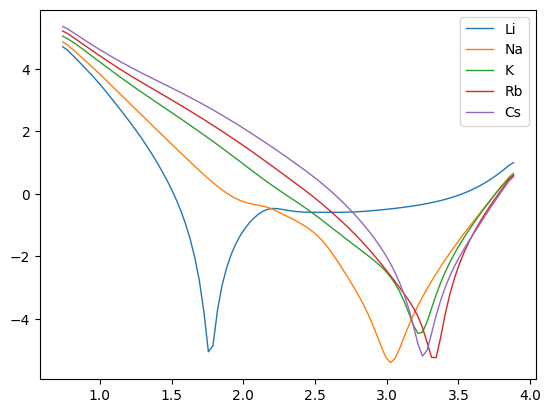

PyObject <matplotlib.legend.Legend object at 0x7fdf22e5ed30>

In [35]:
plot(Li_dists, log.(smooth(Li_Energies, win_len=5) .- minimum(Li_Energies) .+ 0.001), linewidth=1, label="Li")
plot(Na_dists, log.(smooth(Na_Energies, win_len=5) .- minimum(Na_Energies) .+ 0.001), linewidth=1, label="Na")
plot(K_dists, log.(smooth(K_Energies, win_len=10) .- minimum(K_Energies) .+ 0.001), linewidth=1, label="K")
plot(Rb_dists, log.(smooth(Rb_Energies, win_len=5) .- minimum(Rb_Energies) .+ 0.001), linewidth=1, label="Rb")
plot(Cs_dists, log.(smooth(Cs_Energies, win_len=5) .- minimum(Cs_Energies) .+ 0.001), linewidth=1, label="Cs")

legend()

In [39]:
println("Equilibrium distance for Li: ", round(Li_dists[argmin(Li_Energies)], digits=4), " angstroms")
println("Equilibrium distance for Na: ", round(Na_dists[argmin(Na_Energies)], digits=4), " angstroms")
println("Equilibrium distance for K: ", round(K_dists[argmin(K_Energies)], digits=4), " angstroms")
println("Equilibrium distance for Rb: ", round(Rb_dists[argmin(Rb_Energies)], digits=4), " angstroms")
println("Equilibrium distance for Cs: ", round(Cs_dists[argmin(Cs_Energies)], digits=4), " angstroms")

Equilibrium distance for Li: 1.7886 angstroms
Equilibrium distance for Na: 3.0586 angstroms
Equilibrium distance for K: 3.2491 angstroms
Equilibrium distance for Rb: 3.3126 angstroms
Equilibrium distance for Cs: 3.2491 angstroms


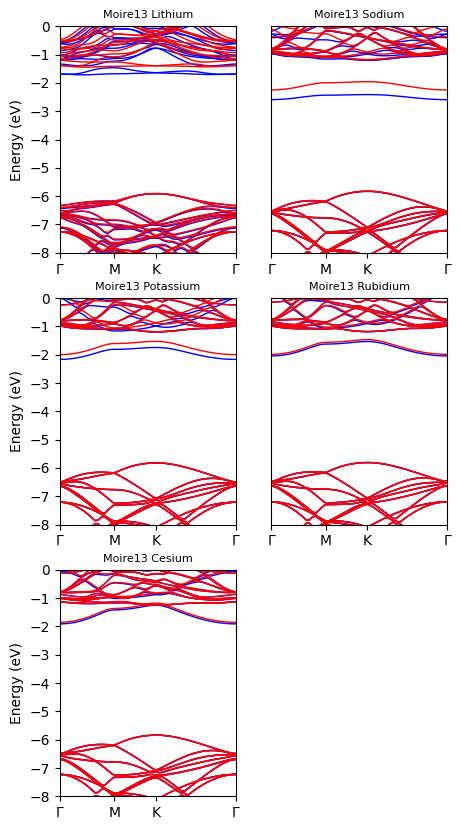

PyObject Text(0.5, 4.4444444444444375, '')

In [40]:
figure(figsize=(5, 10))

subplot(3, 2, 1)
plot_bands("$li_dir/eigenvals/Li-bands-0.169.eigenvals", spin=2, linewidth=1)
ylim(-8,  -0)
title("Moire13 Lithium", fontsize=8)
xlabel("")

subplot(3, 2, 2)
plot_bands("$na_dir/eigenvals/Na-bands-0.289.eigenvals", spin=2, linewidth=1)
ylim(-8,  -0)
title("Moire13 Sodium", fontsize=8)
xlabel("")
yticks([])
ylabel("")

subplot(3, 2, 3)
plot_bands("$k_dir/eigenvals/K-bands-0.307.eigenvals", spin=2, linewidth=1)
ylim(-8,  -0)
title("Moire13 Potassium", fontsize=8)
xlabel("")

subplot(3, 2, 4)
plot_bands("$rb_dir/eigenvals/Rb-bands-0.313.eigenvals", spin=2, linewidth=1)
ylim(-8,  -0)
title("Moire13 Rubidium", fontsize=8)
xlabel("")
yticks([])
ylabel("")

subplot(3, 2, 5)
plot_bands("$cs_dir/eigenvals/Cs-bands-0.307.eigenvals", spin=2, linewidth=1)
ylim(-8,  -0)
title("Moire13 Cesium", fontsize=8)
xlabel("")


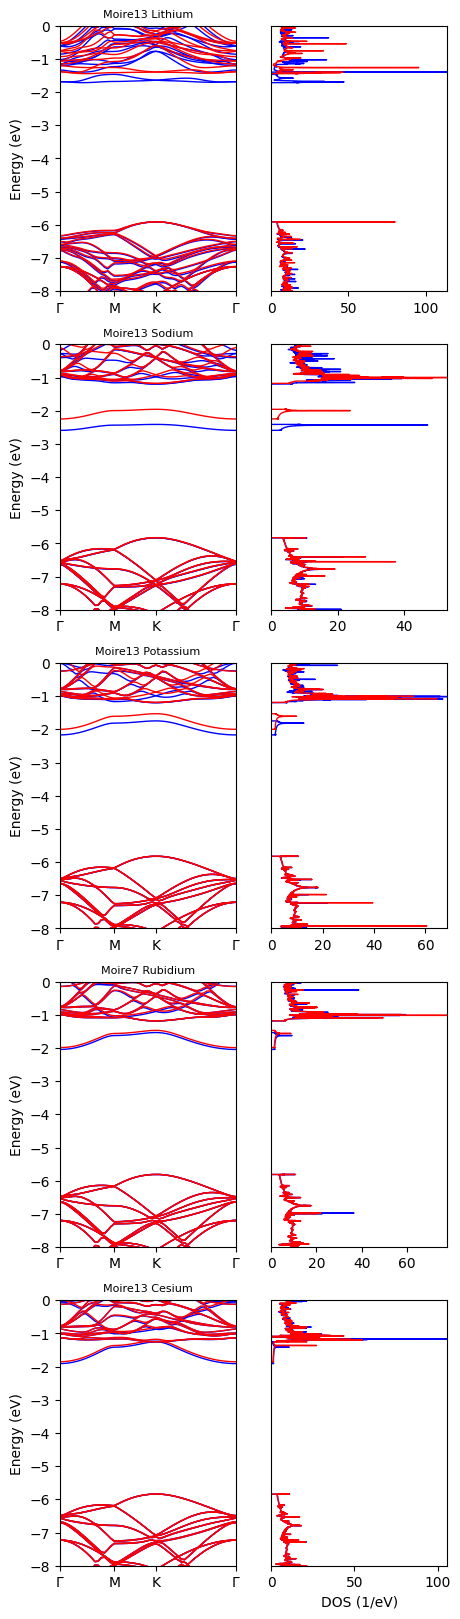

PyObject Text(0.5, 1.0, 'Moire13 Cesium')

In [42]:
figure(figsize=(5, 20))
bands_overlayed_dos("$li_dir/dos/Li-0.169.dosUp","$li_dir/dos/Li-0.169.dosDn", "$li_dir/eigenvals/Li-bands-0.169.eigenvals", dos_yticks=false, linewidth=1,energy_range=(-8, 0)
, band_subplot=[5, 2, 1], dos_subplot=[5, 2, 2])
bands_overlayed_dos("$na_dir/dos/Na-0.289.dosUp","$na_dir/dos/Na-0.289.dosDn", "$na_dir/eigenvals/Na-bands-0.289.eigenvals", dos_yticks=false, linewidth=1,energy_range=(-8, 0), 
band_subplot=[5, 2, 3], dos_subplot=[5, 2, 4])
bands_overlayed_dos("$k_dir/dos/K-0.307.dosUp","$k_dir/dos/K-0.307.dosDn", "$k_dir/eigenvals/K-bands-0.307.eigenvals", dos_yticks=false, linewidth=1, energy_range=(-8, 0), 
band_subplot=[5, 2, 5], dos_subplot=[5, 2, 6])
bands_overlayed_dos("$rb_dir/dos/Rb-0.313.dosUp","$rb_dir/dos/Rb-0.313.dosDn", "$rb_dir/eigenvals/Rb-bands-0.313.eigenvals", dos_yticks=false, linewidth=1,energy_range=(-8, 0), 
band_subplot=[5, 2, 7], dos_subplot=[5, 2, 8])
bands_overlayed_dos("$cs_dir/dos/Cs-0.307.dosUp","$cs_dir/dos/Cs-0.307.dosDn", "$cs_dir/eigenvals/Cs-bands-0.307.eigenvals", dos_yticks=false, linewidth=1, energy_range=(-8, 0), 
band_subplot=[5, 2, 9], dos_subplot=[5, 2, 10])

subplot(5, 2, 2)
xlabel("")
subplot(5, 2, 4)
xlabel("")
subplot(5, 2, 6)
xlabel("")
subplot(5, 2, 8)
xlabel("")
subplot(5, 2, 1)
title("Moire13 Lithium", fontsize=8)
subplot(5, 2, 3)
title("Moire13 Sodium", fontsize=8)
subplot(5, 2, 5)
title("Moire13 Potassium", fontsize=8)
subplot(5, 2, 7)
title("Moire7 Rubidium", fontsize=8)
subplot(5, 2, 9)
title("Moire13 Cesium", fontsize=8)
